In [3]:
import pandas as pd
import numpy as np

nav = pd.read_csv("../data/raw/02_nav_history.csv")

nav['date'] = pd.to_datetime(nav['date'])

results = []

for fund in nav['amfi_code'].unique():
    temp = nav[nav['amfi_code'] == fund].sort_values('date')

    temp['returns'] = temp['nav'].pct_change()

    var95 = np.percentile(temp['returns'].dropna(), 5)

    cvar95 = temp[temp['returns'] <= var95]['returns'].mean()

    results.append([fund, var95, cvar95])

var_cvar = pd.DataFrame(results,
                        columns=['Fund','VaR95','CVaR95'])

var_cvar.to_csv("var_cvar_report.csv", index=False)

print(var_cvar.head())

     Fund     VaR95    CVaR95
0  119551 -0.012846 -0.016397
1  119552 -0.013501 -0.017336
2  119598 -0.024507 -0.030595
3  119599 -0.026859 -0.032384
4  119120 -0.003938 -0.005014


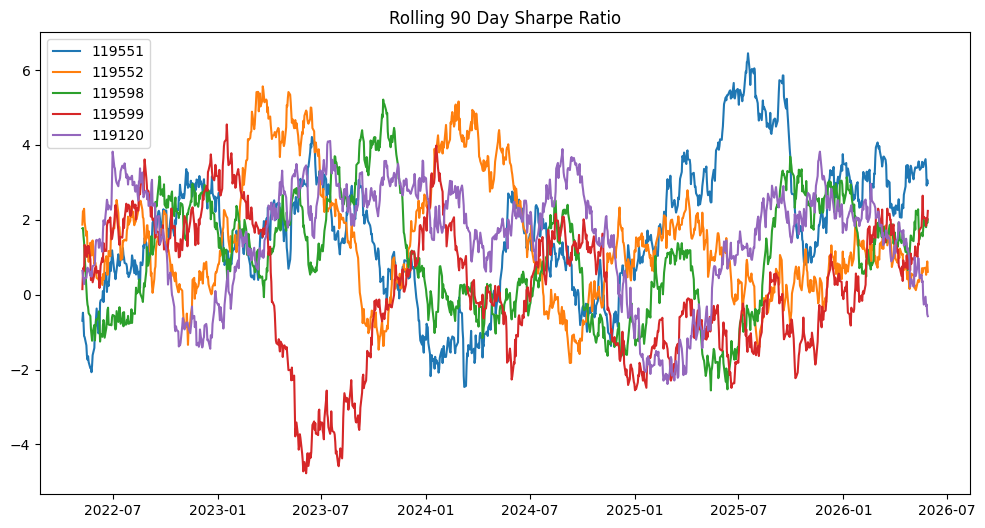

In [4]:
import matplotlib.pyplot as plt
import numpy as np

key_funds = nav['amfi_code'].unique()[:5]

plt.figure(figsize=(12,6))

for fund in key_funds:

    temp = nav[nav['amfi_code']==fund].sort_values('date')

    temp['returns'] = temp['nav'].pct_change()

    temp['rolling_sharpe'] = (
        temp['returns'].rolling(90).mean()
        /
        temp['returns'].rolling(90).std()
    ) * np.sqrt(252)

    plt.plot(temp['date'],
             temp['rolling_sharpe'],
             label=str(fund))

plt.legend()
plt.title("Rolling 90 Day Sharpe Ratio")
plt.savefig("rolling_sharpe_chart.png")
plt.show()

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/raw/02_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [8]:
print(nav.columns)
print(transactions.columns)
print(portfolio.columns)
print(fund_master.columns)

Index(['amfi_code', 'date', 'nav'], dtype='object')
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')
Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')


In [9]:


for name, df in {
    "fund_master": fund_master,
    "nav": nav,
    "transactions": transactions,
    "portfolio": portfolio
}.items():
    print("\n", name)
    print(df.columns.tolist())


 fund_master
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

 nav
['amfi_code', 'date', 'nav']

 transactions
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

 portfolio
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [10]:
import pandas as pd
import numpy as np

nav = pd.read_csv("../data/raw/02_nav_history.csv")

nav['date'] = pd.to_datetime(nav['date'])

results = []

for fund in nav['amfi_code'].unique():

    temp = nav[nav['amfi_code']==fund].sort_values('date')

    temp['daily_return'] = temp['nav'].pct_change()

    returns = temp['daily_return'].dropna()

    if len(returns) > 30:

        var95 = np.percentile(returns,5)

        cvar95 = returns[returns<=var95].mean()

        results.append([
            fund,
            var95,
            cvar95
        ])

var_cvar = pd.DataFrame(
    results,
    columns=['amfi_code','VaR95','CVaR95']
)

var_cvar.to_csv(
    "var_cvar_report.csv",
    index=False
)

var_cvar.head()

,amfi_code,VaR95,CVaR95
0,119551,-0.012846,-0.016397
1,119552,-0.013501,-0.017336
2,119598,-0.024507,-0.030595
3,119599,-0.026859,-0.032384
4,119120,-0.003938,-0.005014


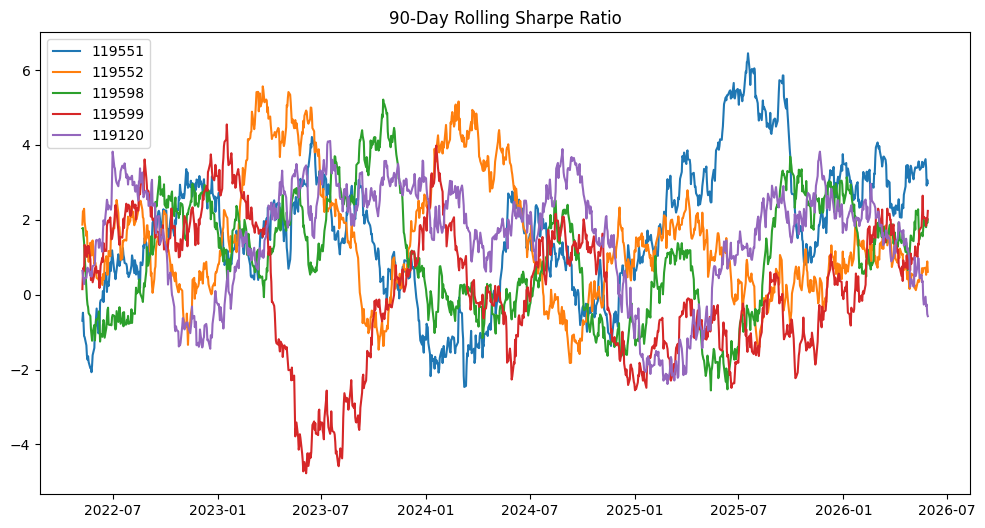

In [11]:
import matplotlib.pyplot as plt
import numpy as np

funds = nav['amfi_code'].unique()[:5]

plt.figure(figsize=(12,6))

for fund in funds:

    temp = nav[
        nav['amfi_code']==fund
    ].sort_values('date')

    temp['daily_return'] = temp['nav'].pct_change()

    temp['rolling_sharpe'] = (
        temp['daily_return']
        .rolling(90)
        .mean()
        /
        temp['daily_return']
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp['date'],
        temp['rolling_sharpe'],
        label=str(fund)
    )

plt.legend()
plt.title("90-Day Rolling Sharpe Ratio")
plt.savefig("rolling_sharpe_chart.png")
plt.show()

In [12]:
txn = pd.read_csv(
    "../data/raw/08_investor_transactions.csv"
)

txn['transaction_date'] = pd.to_datetime(
    txn['transaction_date']
)

first_year = txn.groupby(
    'investor_id'
)['transaction_date'].min().dt.year

txn['cohort_year'] = txn[
    'investor_id'
].map(first_year)

cohort = txn.groupby(
    'cohort_year'
).agg(
    avg_sip=('amount_inr','mean'),
    total_invested=('amount_inr','sum')
)

cohort

,avg_sip,total_invested
cohort_year,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


In [13]:
top_fund = txn.groupby(
    ['cohort_year','amfi_code']
).size().reset_index(name='count')

top_fund = top_fund.loc[
    top_fund.groupby(
        'cohort_year'
    )['count'].idxmax()
]

top_fund

,cohort_year,amfi_code,count
35,2024,148568,874
62,2025,119599,12


In [14]:
sip_txn = txn[
    txn['transaction_type']=="SIP"
].copy()

risk_list = []

for investor in sip_txn['investor_id'].unique():

    temp = sip_txn[
        sip_txn['investor_id']==investor
    ].sort_values(
        'transaction_date'
    )

    if len(temp) >= 6:

        avg_gap = (
            temp['transaction_date']
            .diff()
            .dt.days
            .mean()
        )

        status = (
            "At Risk"
            if avg_gap > 35
            else "Active"
        )

        risk_list.append([
            investor,
            avg_gap,
            status
        ])

sip_risk = pd.DataFrame(
    risk_list,
    columns=[
        'investor_id',
        'avg_gap_days',
        'status'
    ]
)

sip_risk.head()

,investor_id,avg_gap_days,status
0,INV003054,78.666667,At Risk
1,INV001497,63.000000,At Risk
2,INV000786,64.125000,At Risk
3,INV003670,70.857143,At Risk
4,INV001023,72.428571,At Risk


In [15]:
continuity_rate = (
    (sip_risk['status']=="Active")
    .mean()
)*100

print(
    "SIP Continuity Rate:",
    round(continuity_rate,2),
    "%"
)

SIP Continuity Rate: 2.2 %


In [16]:
portfolio = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

hhi_results = []

for fund in portfolio['amfi_code'].unique():

    temp = portfolio[
        portfolio['amfi_code']==fund
    ]

    weights = temp['weight_pct']/100

    hhi = (weights**2).sum()

    hhi_results.append([
        fund,
        hhi
    ])

hhi_df = pd.DataFrame(
    hhi_results,
    columns=['amfi_code','HHI']
)

hhi_df.sort_values(
    'HHI',
    ascending=False
).head()

,amfi_code,HHI
19,119092,0.206448
24,101207,0.200700
3,119599,0.174751
25,102885,0.174709
12,118632,0.168298


In [17]:
sharpe_data = []

for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code']==fund
    ].sort_values('date')

    temp['return'] = temp['nav'].pct_change()

    sharpe = (
        temp['return'].mean()
        /
        temp['return'].std()
    ) * np.sqrt(252)

    sharpe_data.append([
        fund,
        sharpe
    ])

sharpe_df = pd.DataFrame(
    sharpe_data,
    columns=['amfi_code','Sharpe']
)

sharpe_df.sort_values(
    'Sharpe',
    ascending=False
).head(10)

,amfi_code,Sharpe
14,120507,13.655946
23,120844,12.573992
30,101208,12.019194
34,148567,1.906241
22,120843,1.715884
0,119551,1.681289
36,148569,1.602702
15,118632,1.541077
12,120505,1.517047
38,149323,1.498398


In [18]:
print(fund_master['category'].unique())

['Equity' 'Debt']
